# 03 17.1.F NL A16 Realised Cleaning Walkthrough

This notebook walks through the cleaning of ENTSO-E `17.1.F NL A16 (Realised)` step by step:

- inspect the raw XML exports
- parse them into a readable native points table
- diagnose duplicates, sparse positions, gaps, time coverage, and granularity
- derive variable-duration blocks from the change-point structure
- expand those blocks to a canonical quarter-hour UTC table
- aggregate to conservative hourly outputs

The key structural conclusion is:

- this is a sparse `curveType = A03` price series
- points are **change points**, not already-clean quarter-hour rows
- most of the timeline is continuous after block expansion
- a small number of real raw-data gaps remain and are kept explicit


In [1]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import pandas as pd
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 220)
pd.set_option("display.expand_frame_repr", False)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


def load_cleaning_module(repo_root: Path):
    module_path = repo_root / "scripts" / "Data" / "01_cleaning" / "activated_balancing_energy_nl_a16_pipeline.py"
    spec = importlib.util.spec_from_file_location("activated_balancing_energy_nl_a16_notebook", module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


REPO_ROOT = find_repo_root()
cleaning = load_cleaning_module(REPO_ROOT)


In [2]:
RAW_DIR = REPO_ROOT / "data" / "00_Raw" / "ENTSOE" / "17.1 F - Prices of activated balancing energy" / "NL" / "A16 (Realised)"
OUTPUT_DIR = REPO_ROOT / "data" / "01_cleaned" / "Balancing" / "IR Energy" / "17_1_f_nl_a16_realised"
DIAGNOSTICS_DIR = OUTPUT_DIR / "diagnostics"

config_df = pd.DataFrame(
    [
        {"setting": "Raw input directory", "value": str(RAW_DIR)},
        {"setting": "Cleaned output directory", "value": str(OUTPUT_DIR)},
        {"setting": "Market", "value": cleaning.MARKET},
        {"setting": "Reporting timezone", "value": cleaning.MARKET_TIMEZONE},
        {"setting": "Canonical cleaned resolution", "value": cleaning.CANONICAL_RESOLUTION},
        {"setting": "Known-at rule", "value": cleaning.KNOWN_AT_RULE},
    ]
)
config_df


,setting,value
0,Raw input directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\17.1 F - Prices of activated balancing energy\NL\A16 (Realised)
1,Cleaned output directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\IR Energy\17_1_f_nl_a16_realised
2,Market,NL
3,Reporting timezone,Europe/Amsterdam
4,Canonical cleaned resolution,PT15M
5,Known-at rule,realised_a16_not_forecast_safe


## 1. Raw XML Inventory

Start with the file inventory. This confirms the chunked yearly export structure before we touch any parsing logic.


In [3]:
inventory_rows = []
for file_path in sorted(RAW_DIR.glob("*.xml")):
    inventory_rows.append(
        {
            "file": file_path.name,
            "size_mb": round(file_path.stat().st_size / (1024 * 1024), 2),
        }
    )

inventory_df = pd.DataFrame(inventory_rows)
inventory_df


,file,size_mb
0,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,3.71
1,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2023_offset_0000.xml,3.78
2,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2024_offset_0000.xml,3.82
3,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2025_offset_0000.xml,3.94
4,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2022_offset_0000.xml,3.77
5,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2023_offset_0000.xml,3.74
6,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2024_offset_0000.xml,3.87
7,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2025_offset_0000.xml,3.97
8,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_03_2022_offset_0000.xml,3.95
9,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_03_2023_offset_0000.xml,3.89


C:\Users\marijnvalk\AppData\Local\Temp\ipykernel_33208\2927608498.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


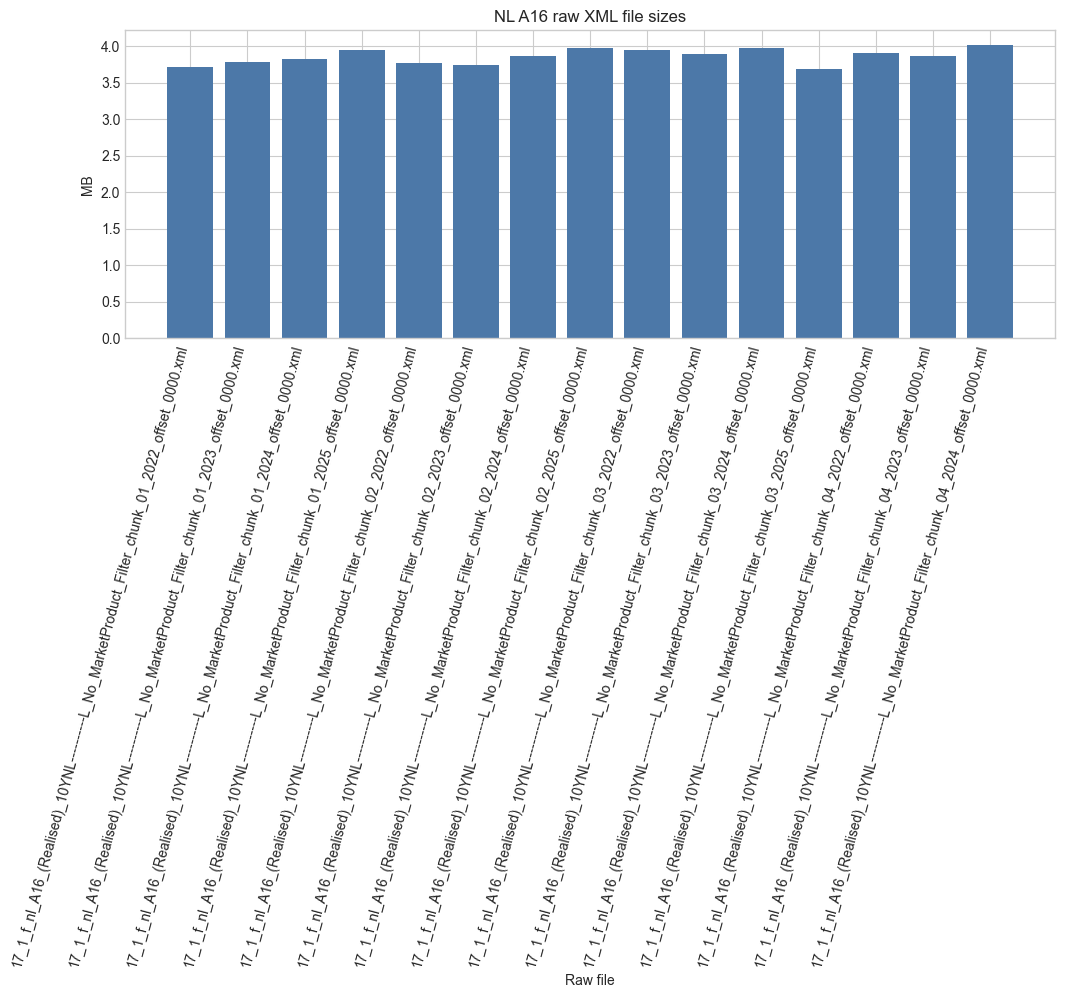

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(inventory_df["file"], inventory_df["size_mb"], color="#4C78A8")
ax.set_title("NL A16 raw XML file sizes")
ax.set_ylabel("MB")
ax.set_xlabel("Raw file")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


## 2. Inspect One Raw XML Snippet

Read the first lines of a raw XML file directly. This makes the payload structure visible:

- `type = A84`
- `process = A16`
- one `TimeSeries` per direction
- sparse `Point` positions with `activation_Price.amount`


In [5]:
sample_path = sorted(RAW_DIR.glob("*.xml"))[0]
sample_text = sample_path.read_text(encoding="utf-8", errors="replace")

print("File:", sample_path.name)
print()
print("\n".join(sample_text.splitlines()[:70]))


File: 17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml

<?xml version="1.0" encoding="utf-8"?>
<Balancing_MarketDocument xmlns="urn:iec62325.351:tc57wg16:451-6:balancingdocument:4:1">
  <mRID>f8b9e0fb82c54de8a6f34a7e7f5e55ce</mRID>
  <revisionNumber>1</revisionNumber>
  <type>A84</type>
  <process.processType>A16</process.processType>
  <sender_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</sender_MarketParticipant.mRID>
  <sender_MarketParticipant.marketRole.type>A32</sender_MarketParticipant.marketRole.type>
  <receiver_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</receiver_MarketParticipant.mRID>
  <receiver_MarketParticipant.marketRole.type>A33</receiver_MarketParticipant.marketRole.type>
  <createdDateTime>2026-03-31T12:28:19Z</createdDateTime>
  <area_Domain.mRID codingScheme="A01">10YNL----------L</area_Domain.mRID>
  <period.timeInterval>
    <start>2022-01-01T00:00Z</start>
    <end>2022-04-01T00:00Z</en

## 3. Parse Raw XML Into a Readable Native Points Table


In [6]:
points_raw, file_summary_df, parse_errors_df = cleaning.parse_xml_files(RAW_DIR)

print(f"Point rows parsed: {len(points_raw):,}")
print(f"Files parsed: {len(file_summary_df):,}")
print(f"Parse errors: {len(parse_errors_df):,}")

file_summary_df


Point rows parsed: 241,476
Files parsed: 15
Parse errors: 0


,source_file,size_kb,created_datetime_utc,document_type_code,process_type_code,document_period_start_utc,document_period_end_utc,point_rows,period_count,flow_direction_distribution,reported_resolution_distribution,price_category_distribution
0,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,3799.0,2026-03-31T12:28:19+00:00,A84,A16,2022-01-01T00:00:00+00:00,2022-04-01T00:00:00+00:00,15470,2,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 2}","{""A06"": 15470}"
1,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2023_offset_0000.xml,3865.9,2026-03-31T12:28:35+00:00,A84,A16,2023-01-01T00:00:00+00:00,2023-04-01T00:00:00+00:00,15748,4,"{""A01"": 2, ""A02"": 2}","{""PT15M"": 4}","{""A06"": 15748}"
2,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2024_offset_0000.xml,3908.2,2026-03-31T12:29:04+00:00,A84,A16,2024-01-01T00:00:00+00:00,2024-04-01T00:00:00+00:00,15930,2,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 2}","{""A06"": 15930}"
3,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2025_offset_0000.xml,4031.2,2026-03-31T12:30:16+00:00,A84,A16,2025-01-01T00:00:00+00:00,2025-04-01T00:00:00+00:00,16420,2,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 2}","{""A06"": 16420}"
4,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2022_offset_0000.xml,3860.8,2026-03-31T12:28:23+00:00,A84,A16,2022-04-01T00:00:00+00:00,2022-07-01T00:00:00+00:00,15722,2,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 2}","{""A06"": 15722}"
5,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2023_offset_0000.xml,3834.2,2026-03-31T12:28:40+00:00,A84,A16,2023-04-01T00:00:00+00:00,2023-07-01T00:00:00+00:00,15628,6,"{""A01"": 3, ""A02"": 3}","{""PT15M"": 6}","{""A06"": 15628}"
6,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2024_offset_0000.xml,3964.3,2026-03-31T12:29:17+00:00,A84,A16,2024-04-01T00:00:00+00:00,2024-07-01T00:00:00+00:00,16162,4,"{""A01"": 2, ""A02"": 2}","{""PT15M"": 4}","{""A06"": 16162}"
7,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2025_offset_0000.xml,4070.3,2026-03-31T12:31:10+00:00,A84,A16,2025-04-01T00:00:00+00:00,2025-07-01T00:00:00+00:00,16598,2,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 2}","{""A06"": 16598}"
8,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_03_2022_offset_0000.xml,4042.3,2026-03-31T12:28:28+00:00,A84,A16,2022-07-01T00:00:00+00:00,2022-10-01T00:00:00+00:00,16456,2,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 2}","{""A06"": 16456}"
9,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_03_2023_offset_0000.xml,3988.0,2026-03-31T12:28:43+00:00,A84,A16,2023-07-01T00:00:00+00:00,2023-10-01T00:00:00+00:00,16258,2,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 2}","{""A06"": 16258}"


In [7]:
if not parse_errors_df.empty:
    parse_errors_df
else:
    print("No parse errors.")

readable_points = (
    points_raw[
        [
            "source_file",
            "flow_direction_label",
            "series_period_start_utc",
            "series_period_end_utc",
            "reported_resolution",
            "point_position",
            "point_timestamp_utc",
            "activation_price_eur_per_mwh",
            "imbalance_price_category_code",
        ]
    ]
    .sort_values(["point_timestamp_utc", "flow_direction_label", "point_position"])
    .reset_index(drop=True)
)
readable_points.head(20)


No parse errors.


,source_file,flow_direction_label,series_period_start_utc,series_period_end_utc,reported_resolution,point_position,point_timestamp_utc,activation_price_eur_per_mwh,imbalance_price_category_code
0,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Down,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,1,2022-01-01 00:00:00+00:00,112.66,A06
1,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Up,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,1,2022-01-01 00:00:00+00:00,0.00,A06
2,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Down,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,2,2022-01-01 00:15:00+00:00,0.00,A06
3,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Up,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,2,2022-01-01 00:15:00+00:00,0.00,A06
4,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Down,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,4,2022-01-01 00:45:00+00:00,129.70,A06
5,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Up,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,4,2022-01-01 00:45:00+00:00,0.00,A06
6,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Down,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,5,2022-01-01 01:00:00+00:00,0.00,A06
7,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Up,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,5,2022-01-01 01:00:00+00:00,174.76,A06
8,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Down,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,6,2022-01-01 01:15:00+00:00,0.00,A06
9,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,Up,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,6,2022-01-01 01:15:00+00:00,180.76,A06


## 4. Diagnose Structure, Duplicates, and Period Compression


In [8]:
points_long, duplicates_removed = cleaning.deduplicate_points(points_raw)
period_diagnostics = cleaning.build_period_diagnostics(points_long)
points_summary = cleaning.summarize_points(points_long)

overview_df = pd.DataFrame(
    [
        {"metric": "Point rows after deduplication", "value": len(points_long)},
        {"metric": "Duplicates removed", "value": len(duplicates_removed)},
        {"metric": "Unique directions", "value": ", ".join(sorted(points_long["flow_direction_label"].dropna().unique()))},
        {"metric": "Unique resolutions", "value": ", ".join(sorted(points_long["reported_resolution"].dropna().unique()))},
        {"metric": "Unique imbalance price categories", "value": ", ".join(sorted(points_long["imbalance_price_category_code"].dropna().unique()))},
        {"metric": "Min point timestamp UTC", "value": points_long["point_timestamp_utc"].min()},
        {"metric": "Max point timestamp UTC", "value": points_long["point_timestamp_utc"].max()},
    ]
)
overview_df


,metric,value
0,Point rows after deduplication,241476
1,Duplicates removed,0
2,Unique directions,"Down, Up"
3,Unique resolutions,PT15M
4,Unique imbalance price categories,A06
5,Min point timestamp UTC,2022-01-01 00:00:00+00:00
6,Max point timestamp UTC,2025-09-26 06:30:00+00:00


In [9]:
points_summary


,flow_direction_code,flow_direction_label,rows,unique_periods,min_point_timestamp_utc,max_point_timestamp_utc,min_local_delivery_date,max_local_delivery_date,reported_resolution_distribution,point_count_distribution,price_category_distribution
0,A01,Up,120738,22,2022-01-01T00:00:00+00:00,2025-09-26T06:30:00+00:00,2022-01-01,2025-09-26,"{""PT15M"": 120738}","{""116"": 116, ""1707"": 1707, ""1893"": 1893, ""3"": 3, ""4023"": 4023, ""4058"": 4058, ""435"": 435, ""5672"": 5672, ""5981"": 5981, ""6737"": 6737, ""7735"": 7735, ""7861"": 7861, ""7965"": 7965, ""8055"": 8055, ""8129"": 8129, ""8146"": 8146, ""820"": 820, ""8210"": 8210, ""8228"": 8228, ""8287"": 8287, ""8299"": 8299, ""8378"": 8378}","{""A06"": 120738}"
1,A02,Down,120738,22,2022-01-01T00:00:00+00:00,2025-09-26T06:30:00+00:00,2022-01-01,2025-09-26,"{""PT15M"": 120738}","{""116"": 116, ""1707"": 1707, ""1893"": 1893, ""3"": 3, ""4023"": 4023, ""4058"": 4058, ""435"": 435, ""5672"": 5672, ""5981"": 5981, ""6737"": 6737, ""7735"": 7735, ""7861"": 7861, ""7965"": 7965, ""8055"": 8055, ""8129"": 8129, ""8146"": 8146, ""820"": 820, ""8210"": 8210, ""8228"": 8228, ""8287"": 8287, ""8299"": 8299, ""8378"": 8378}","{""A06"": 120738}"


In [10]:
period_diagnostics.head(20)


,source_file,timeseries_index,timeseries_mrid,period_index,flow_direction_code,flow_direction_label,business_type_code,psr_type_code,curve_type_code,curve_type_label,series_period_start_utc,series_period_end_utc,reported_resolution,reported_resolution_minutes,expected_dense_point_count,point_count,first_position,last_position,first_point_timestamp_utc,last_point_timestamp_utc,unique_price_levels,unique_price_categories,period_duration_minutes,compression_ratio_vs_dense_grid,first_position_gt_1,has_sparse_gaps_between_positions
0,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,1,1,1,A01,Up,A97,A03,A03,Variable_block_curve,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,8640,7735,1,8640,2022-01-01 00:00:00+00:00,2022-03-31 23:45:00+00:00,3353,1,129600,0.895255,False,True
1,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,2,2,1,A02,Down,A97,A03,A03,Variable_block_curve,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,8640,7735,1,8640,2022-01-01 00:00:00+00:00,2022-03-31 23:45:00+00:00,2682,1,129600,0.895255,False,True
2,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2022_offset_0000.xml,1,1,1,A01,Up,A97,A03,A03,Variable_block_curve,2022-04-01 00:00:00+00:00,2022-07-01 00:00:00+00:00,PT15M,15,8736,7861,1,8736,2022-04-01 00:00:00+00:00,2022-06-30 23:45:00+00:00,3415,1,131040,0.89984,False,True
3,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_02_2022_offset_0000.xml,2,2,1,A02,Down,A97,A03,A03,Variable_block_curve,2022-04-01 00:00:00+00:00,2022-07-01 00:00:00+00:00,PT15M,15,8736,7861,1,8736,2022-04-01 00:00:00+00:00,2022-06-30 23:45:00+00:00,2745,1,131040,0.89984,False,True
4,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_03_2022_offset_0000.xml,1,1,1,A01,Up,A97,A03,A03,Variable_block_curve,2022-07-01 00:00:00+00:00,2022-10-01 00:00:00+00:00,PT15M,15,8832,8228,1,8832,2022-07-01 00:00:00+00:00,2022-09-30 23:45:00+00:00,3874,1,132480,0.931612,False,True
5,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_03_2022_offset_0000.xml,2,2,1,A02,Down,A97,A03,A03,Variable_block_curve,2022-07-01 00:00:00+00:00,2022-10-01 00:00:00+00:00,PT15M,15,8832,8228,1,8832,2022-07-01 00:00:00+00:00,2022-09-30 23:45:00+00:00,3114,1,132480,0.931612,False,True
6,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_04_2022_offset_0000.xml,1,1,1,A01,Up,A97,A03,A03,Variable_block_curve,2022-10-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,PT15M,15,8832,8146,1,8832,2022-10-01 00:00:00+00:00,2022-12-31 23:45:00+00:00,3593,1,132480,0.922328,False,True
7,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_04_2022_offset_0000.xml,2,2,1,A02,Down,A97,A03,A03,Variable_block_curve,2022-10-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,PT15M,15,8832,8146,1,8832,2022-10-01 00:00:00+00:00,2022-12-31 23:45:00+00:00,2901,1,132480,0.922328,False,True
8,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2023_offset_0000.xml,1,1,1,A01,Up,A97,A03,A03,Variable_block_curve,2023-01-01 00:00:00+00:00,2023-03-10 04:00:00+00:00,PT15M,15,6544,5981,1,6544,2023-01-01 00:00:00+00:00,2023-03-10 03:45:00+00:00,2377,1,98160,0.913967,False,True
9,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2023_offset_0000.xml,2,2,1,A02,Down,A97,A03,A03,Variable_block_curve,2023-01-01 00:00:00+00:00,2023-03-10 04:00:00+00:00,PT15M,15,6544,5981,1,6544,2023-01-01 00:00:00+00:00,2023-03-10 03:45:00+00:00,2139,1,98160,0.913967,False,True


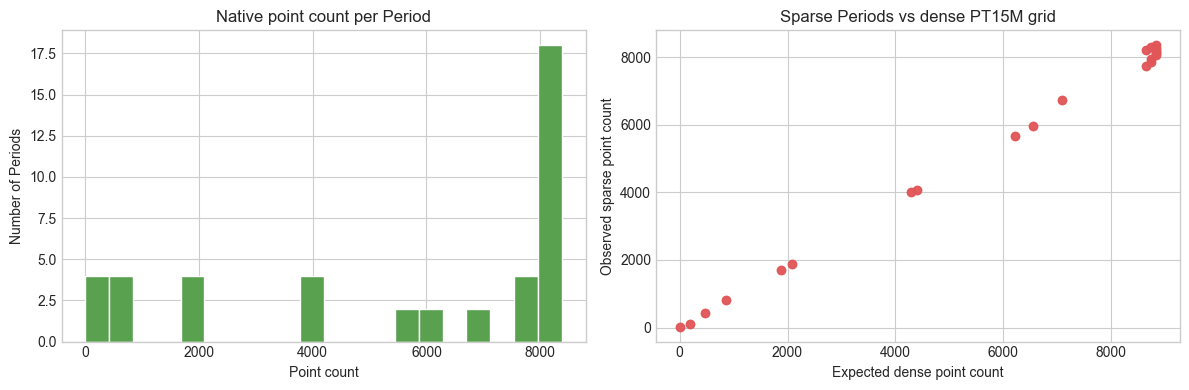

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(period_diagnostics["point_count"], bins=20, color="#59A14F", edgecolor="white")
axes[0].set_title("Native point count per Period")
axes[0].set_xlabel("Point count")
axes[0].set_ylabel("Number of Periods")

axes[1].scatter(
    period_diagnostics["expected_dense_point_count"],
    period_diagnostics["point_count"],
    s=35,
    alpha=0.8,
    color="#E15759",
)
axes[1].set_title("Sparse Periods vs dense PT15M grid")
axes[1].set_xlabel("Expected dense point count")
axes[1].set_ylabel("Observed sparse point count")

plt.tight_layout()
plt.show()


## 5. Turn Change Points Into Blocks

Each point becomes the start of a block. The block ends at the next point or at the end of the Period.


In [12]:
blocks_long = cleaning.build_blocks(points_long)
blocks_summary = cleaning.summarize_blocks(blocks_long)

print(f"Block rows: {len(blocks_long):,}")
blocks_long.head(20)


Block rows: 241,476


,block_id,family,market,source_file,created_datetime_utc,document_type_code,document_type_label,process_type_code,process_type_label,area_domain,timeseries_index,timeseries_mrid,period_index,business_type_code,business_type_label,psr_type_code,flow_direction_code,flow_direction_label,curve_type_code,curve_type_label,currency_unit,price_measure_unit,series_period_start_utc,series_period_end_utc,reported_resolution,reported_resolution_minutes,point_count_in_period,expected_dense_point_count,point_position,native_point_timestamp_utc,next_point_position,next_point_timestamp_utc,block_start_utc,block_end_utc,block_duration_minutes,block_quarterhour_count,block_position_step,block_interpretation,activation_price_eur_per_mwh,imbalance_price_category_code,imbalance_price_category_label
0,1,17_1_f_nl_a16_realised,NL,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,2026-03-31 12:28:19+00:00,A84,A84,A16,A16,10YNL----------L,1,1,1,A97,A97,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,7735,8640,1,2022-01-01 00:00:00+00:00,2,2022-01-01 00:15:00+00:00,2022-01-01 00:00:00+00:00,2022-01-01 00:15:00+00:00,15,1,1,change_point_to_next_position,0.00,A06,A06
1,7736,17_1_f_nl_a16_realised,NL,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,2026-03-31 12:28:19+00:00,A84,A84,A16,A16,10YNL----------L,2,2,1,A97,A97,A03,A02,Down,A03,Variable_block_curve,EUR,MWH,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,7735,8640,1,2022-01-01 00:00:00+00:00,2,2022-01-01 00:15:00+00:00,2022-01-01 00:00:00+00:00,2022-01-01 00:15:00+00:00,15,1,1,change_point_to_next_position,112.66,A06,A06
2,2,17_1_f_nl_a16_realised,NL,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,2026-03-31 12:28:19+00:00,A84,A84,A16,A16,10YNL----------L,1,1,1,A97,A97,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,7735,8640,2,2022-01-01 00:15:00+00:00,4,2022-01-01 00:45:00+00:00,2022-01-01 00:15:00+00:00,2022-01-01 00:45:00+00:00,30,2,2,change_point_to_next_position,0.00,A06,A06
3,7737,17_1_f_nl_a16_realised,NL,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,2026-03-31 12:28:19+00:00,A84,A84,A16,A16,10YNL----------L,2,2,1,A97,A97,A03,A02,Down,A03,Variable_block_curve,EUR,MWH,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,7735,8640,2,2022-01-01 00:15:00+00:00,4,2022-01-01 00:45:00+00:00,2022-01-01 00:15:00+00:00,2022-01-01 00:45:00+00:00,30,2,2,change_point_to_next_position,0.00,A06,A06
4,3,17_1_f_nl_a16_realised,NL,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,2026-03-31 12:28:19+00:00,A84,A84,A16,A16,10YNL----------L,1,1,1,A97,A97,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,7735,8640,4,2022-01-01 00:45:00+00:00,5,2022-01-01 01:00:00+00:00,2022-01-01 00:45:00+00:00,2022-01-01 01:00:00+00:00,15,1,1,change_point_to_next_position,0.00,A06,A06
5,7738,17_1_f_nl_a16_realised,NL,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,2026-03-31 12:28:19+00:00,A84,A84,A16,A16,10YNL----------L,2,2,1,A97,A97,A03,A02,Down,A03,Variable_block_curve,EUR,MWH,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,7735,8640,4,2022-01-01 00:45:00+00:00,5,2022-01-01 01:00:00+00:00,2022-01-01 00:45:00+00:00,2022-01-01 01:00:00+00:00,15,1,1,change_point_to_next_position,129.70,A06,A06
6,4,17_1_f_nl_a16_realised,NL,17_1_f_nl_A16_(Realised)_10YNL----------L_No_MarketProduct_Filter_chunk_01_2022_offset_0000.xml,2026-03-31 12:28:19+00:00,A84,A84,A16,A16,10YNL----------L,1,1,1,A97,A97,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-01-01 00:00:00+00:00,2022-04-01 00:00:00+00:00,PT15M,15,7735,8640,5,2022-01-01 01:00:00+00:00,6,2022-01-01 01:15

In [13]:
blocks_summary


,flow_direction_code,flow_direction_label,rows,min_block_start_utc,max_block_end_utc,min_block_duration_minutes,max_block_duration_minutes,block_duration_distribution
0,A01,Up,120738,2022-01-01T00:00:00+00:00,2025-09-26T06:45:00+00:00,15,1095,"{""105"": 22, ""1095"": 1, ""120"": 15, ""135"": 6, ""15"": 113579, ""150"": 5, ""165"": 2, ""180"": 1, ""210"": 2, ""240"": 2, ""30"": 5676, ""45"": 962, ""465"": 1, ""495"": 1, ""60"": 292, ""75"": 116, ""90"": 55}"
1,A02,Down,120738,2022-01-01T00:00:00+00:00,2025-09-26T06:45:00+00:00,15,1095,"{""105"": 22, ""1095"": 1, ""120"": 15, ""135"": 6, ""15"": 113579, ""150"": 5, ""165"": 2, ""180"": 1, ""210"": 2, ""240"": 2, ""30"": 5676, ""45"": 962, ""465"": 1, ""495"": 1, ""60"": 292, ""75"": 116, ""90"": 55}"


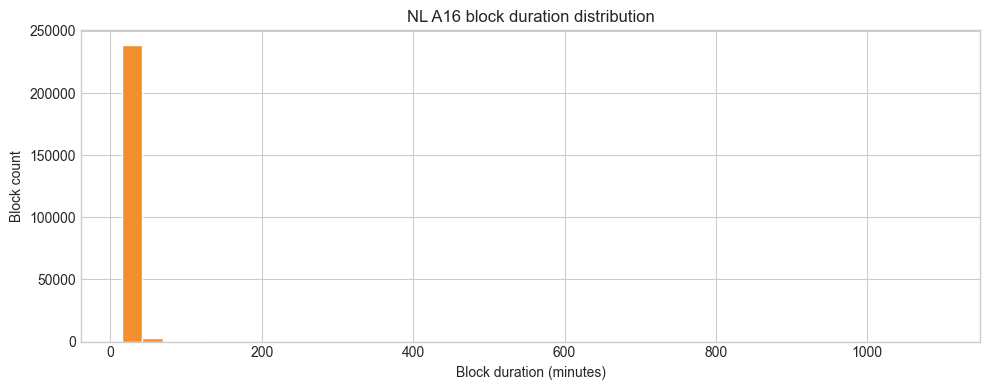

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(blocks_long["block_duration_minutes"], bins=40, color="#F28E2B", edgecolor="white")
ax.set_title("NL A16 block duration distribution")
ax.set_xlabel("Block duration (minutes)")
ax.set_ylabel("Block count")
plt.tight_layout()
plt.show()


## 6. Expand Blocks to Canonical Quarter-Hour Rows and Inspect Gaps


In [15]:
quarterhour_long = cleaning.expand_blocks_to_quarterhour(blocks_long)
quarterhour_wide = cleaning.build_quarterhour_wide(quarterhour_long)
quarterhour_summary = cleaning.summarize_quarterhour(quarterhour_long)
gap_intervals, gap_summary = cleaning.find_gap_intervals(quarterhour_long)

print(f"Quarter-hour rows: {len(quarterhour_long):,}")
quarterhour_summary


Quarter-hour rows: 261,008


,flow_direction_code,flow_direction_label,rows,unique_intervals,min_timestamp_utc,max_interval_end_utc,min_local_delivery_date,max_local_delivery_date
0,A01,Up,130504,130504,2022-01-01T00:00:00+00:00,2025-09-26T06:45:00+00:00,2022-01-01,2025-09-26
1,A02,Down,130504,130504,2022-01-01T00:00:00+00:00,2025-09-26T06:45:00+00:00,2022-01-01,2025-09-26


In [16]:
gap_summary


,gap_start_utc,missing_quarterhours,gap_end_utc,market,flow_direction_code,flow_direction_label,merged_gap_count
0,2023-03-10 04:00:00+00:00,18,2023-03-10 08:30:00+00:00,NL,A01,Up,1
1,2023-04-05 22:00:00+00:00,35,2023-04-06 06:45:00+00:00,NL,A01,Up,2
2,2023-04-25 22:00:00+00:00,131,2023-04-27 06:45:00+00:00,NL,A01,Up,3
3,2024-05-16 22:00:00+00:00,33,2024-05-17 06:15:00+00:00,NL,A01,Up,4
4,2025-07-09 22:00:00+00:00,154,2025-07-11 12:30:00+00:00,NL,A01,Up,5
5,2025-07-11 13:15:00+00:00,35,2025-07-11 22:00:00+00:00,NL,A01,Up,6
6,2025-07-13 22:00:00+00:00,61,2025-07-14 13:15:00+00:00,NL,A01,Up,7
7,2023-03-10 04:00:00+00:00,18,2023-03-10 08:30:00+00:00,NL,A02,Down,1
8,2023-04-05 22:00:00+00:00,35,2023-04-06 06:45:00+00:00,NL,A02,Down,2
9,2023-04-25 22:00:00+00:00,131,2023-04-27 06:45:00+00:00,NL,A02,Down,3


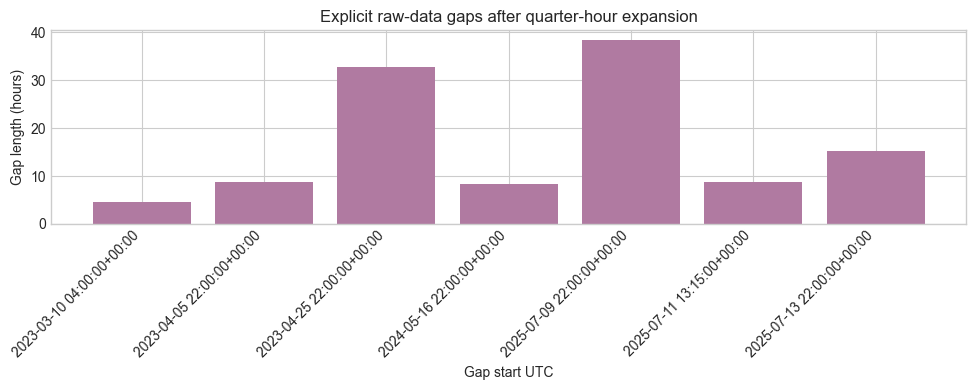

In [17]:
if not gap_summary.empty:
    gap_plot = gap_summary.copy()
    gap_plot["gap_hours"] = gap_plot["missing_quarterhours"] * 0.25

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(gap_plot["gap_start_utc"].astype(str), gap_plot["gap_hours"], color="#B07AA1")
    ax.set_title("Explicit raw-data gaps after quarter-hour expansion")
    ax.set_xlabel("Gap start UTC")
    ax.set_ylabel("Gap length (hours)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No quarter-hour gaps detected.")


## 7. Visualise an Objective High-Volatility Week

Pick the week with the highest 7-day rolling mean of daily quarter-hour price standard deviation. This avoids hand-picking a plot.


In [18]:
qh_plot = quarterhour_long.copy()
qh_plot["local_date"] = qh_plot["timestamp_utc"].dt.tz_convert(cleaning.MARKET_TIMEZONE).dt.date
daily_std = (
    qh_plot.groupby(["local_date", "flow_direction_label"], as_index=False)
    .agg(daily_std=("activation_price_eur_per_mwh", "std"))
)
daily_score = (
    daily_std.groupby("local_date", as_index=False)
    .agg(score=("daily_std", "mean"))
    .sort_values("local_date")
)
daily_score["rolling_score"] = daily_score["score"].rolling(7, min_periods=3).mean()
sample_week_start = pd.to_datetime(daily_score.loc[daily_score["rolling_score"].idxmax(), "local_date"])
sample_week_end = sample_week_start + pd.Timedelta(days=7)

print("Selected local week start:", sample_week_start.date())
print("Selected local week end:", sample_week_end.date())


Selected local week start: 2022-08-29
Selected local week end: 2022-09-05


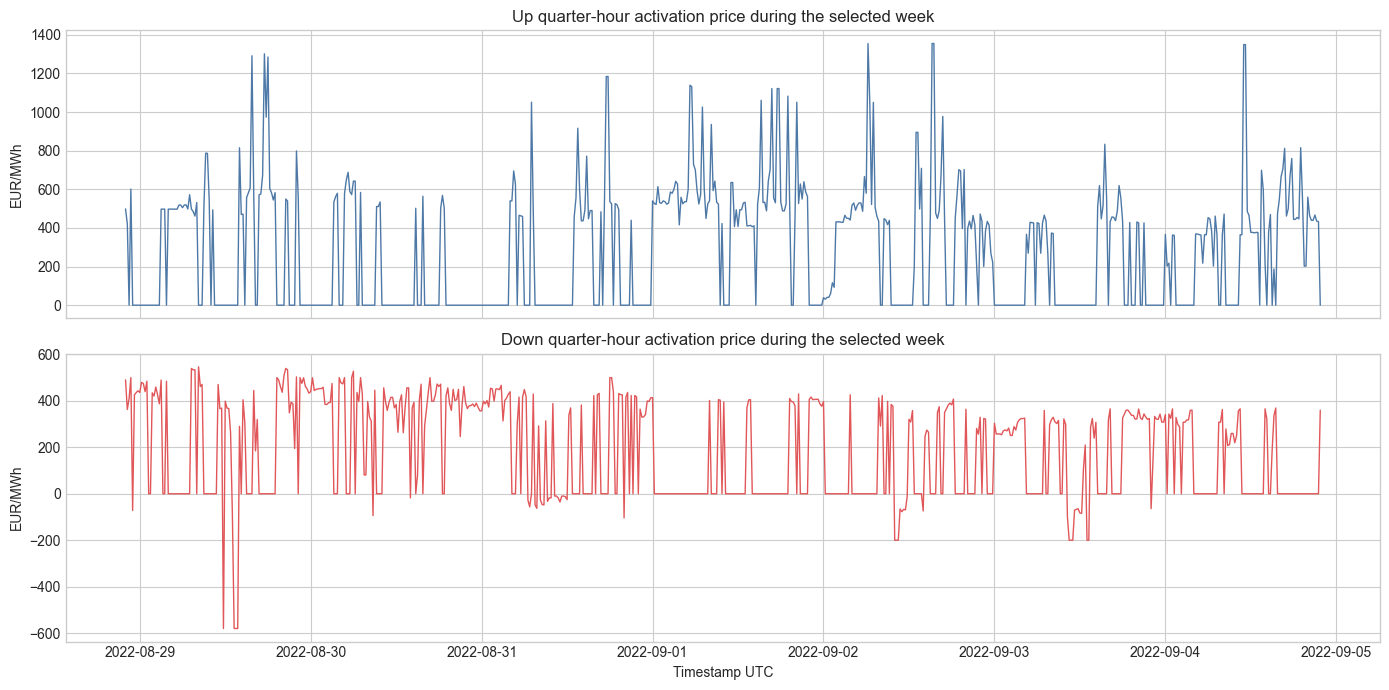

In [19]:
week_view = qh_plot[
    (qh_plot["timestamp_utc"].dt.tz_convert(cleaning.MARKET_TIMEZONE) >= sample_week_start.tz_localize(cleaning.MARKET_TIMEZONE))
    & (qh_plot["timestamp_utc"].dt.tz_convert(cleaning.MARKET_TIMEZONE) < sample_week_end.tz_localize(cleaning.MARKET_TIMEZONE))
].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, direction in zip(axes, ["Up", "Down"]):
    sub = week_view.loc[week_view["flow_direction_label"] == direction]
    ax.plot(sub["timestamp_utc"], sub["activation_price_eur_per_mwh"], linewidth=1.0, color="#4E79A7" if direction == "Up" else "#E15759")
    ax.set_title(f"{direction} quarter-hour activation price during the selected week")
    ax.set_ylabel("EUR/MWh")
axes[-1].set_xlabel("Timestamp UTC")
plt.tight_layout()
plt.show()


## 8. Aggregate to Hourly and Keep Incomplete Hours Explicit


In [20]:
hourly_long = cleaning.aggregate_hourly(quarterhour_long)
hourly_wide = cleaning.build_hourly_wide(hourly_long)
hourly_summary = cleaning.summarize_hourly(hourly_long)

print(f"Hourly rows: {len(hourly_long):,}")
hourly_summary


Hourly rows: 65,260


,flow_direction_code,flow_direction_label,rows,unique_hours,incomplete_hours,min_timestamp_utc,max_interval_end_utc,min_local_delivery_date,max_local_delivery_date
0,A01,Up,32630,32630,8,2022-01-01T00:00:00+00:00,2025-09-26T07:00:00+00:00,2022-01-01,2025-09-26
1,A02,Down,32630,32630,8,2022-01-01T00:00:00+00:00,2025-09-26T07:00:00+00:00,2022-01-01,2025-09-26


In [21]:
incomplete_hours = hourly_long.loc[~hourly_long["is_complete_hour"]].copy()
incomplete_hours.head(20)


,family,market,timestamp_utc,interval_end_utc,activation_price_mean_eur_per_mwh,activation_price_min_eur_per_mwh,activation_price_max_eur_per_mwh,activation_price_spread_eur_per_mwh,quarterhour_count,coverage_minutes,expected_coverage_minutes,is_complete_hour,source_block_count,source_file_count,unique_price_category_count,price_categories_json,flow_direction_code,flow_direction_label,curve_type_code,curve_type_label,target_delivery_local_date,target_hour_local,target_minute_local,known_at_utc,known_at_rule
20792,17_1_f_nl_a16_realised,NL,2023-03-10 08:00:00+00:00,2023-03-10 09:00:00+00:00,NaN,NaN,NaN,NaN,2,30,60,False,2,1,1,"{""A06"": 2}",A01,Up,A03,Variable_block_curve,2023-03-10,9,0,NaT,realised_a16_not_forecast_safe
20793,17_1_f_nl_a16_realised,NL,2023-03-10 08:00:00+00:00,2023-03-10 09:00:00+00:00,NaN,NaN,NaN,NaN,2,30,60,False,2,1,1,"{""A06"": 2}",A02,Down,A03,Variable_block_curve,2023-03-10,9,0,NaT,realised_a16_not_forecast_safe
22068,17_1_f_nl_a16_realised,NL,2023-04-06 06:00:00+00:00,2023-04-06 07:00:00+00:00,NaN,NaN,NaN,NaN,1,15,60,False,1,1,1,"{""A06"": 1}",A01,Up,A03,Variable_block_curve,2023-04-06,8,0,NaT,realised_a16_not_forecast_safe
22069,17_1_f_nl_a16_realised,NL,2023-04-06 06:00:00+00:00,2023-04-06 07:00:00+00:00,NaN,NaN,NaN,NaN,1,15,60,False,1,1,1,"{""A06"": 1}",A02,Down,A03,Variable_block_curve,2023-04-06,8,0,NaT,realised_a16_not_forecast_safe
23012,17_1_f_nl_a16_realised,NL,2023-04-27 06:00:00+00:00,2023-04-27 07:00:00+00:00,NaN,NaN,NaN,NaN,1,15,60,False,1,1,1,"{""A06"": 1}",A01,Up,A03,Variable_block_curve,2023-04-27,8,0,NaT,realised_a16_not_forecast_safe
23013,17_1_f_nl_a16_realised,NL,2023-04-27 06:00:00+00:00,2023-04-27 07:00:00+00:00,NaN,NaN,NaN,NaN,1,15,60,False,1,1,1,"{""A06"": 1}",A02,Down,A03,Variable_block_curve,2023-04-27,8,0,NaT,realised_a16_not_forecast_safe
41524,17_1_f_nl_a16_realised,NL,2024-05-17 06:00:00+00:00,2024-05-17 07:00:00+00:00,NaN,NaN,NaN,NaN,3,45,60,False,3,1,1,"{""A06"": 3}",A01,Up,A03,Variable_block_curve,2024-05-17,8,0,NaT,realised_a16_not_forecast_safe
41525,17_1_f_nl_a16_realised,NL,2024-05-17 06:00:00+00:00,2024-05-17 07:00:00+00:00,NaN,NaN,NaN,NaN,3,45,60,False,3,1,1,"{""A06"": 3}",A02,Down,A03,Variable_block_curve,2024-05-17,8,0,NaT,realised_a16_not_forecast_safe
61620,17_1_f_nl_a16_realised,NL,2025-07-11 12:00:00+00:00,2025-07-11 13:00:00+00:00,NaN,NaN,NaN,NaN,2,30,60,False,2,1,1,"{""A06"": 2}",A01,Up,A03,Variable_block_curve,2025-07-11,14,0,NaT,realised_a16_not_forecast_safe
61621,17_1_f_nl_a16_realised,NL,2025-07-11 12:00:00+00:00,2025-07-11 13:00:00+00:00,NaN,NaN,NaN,NaN,2,30,60,False,2,1,1,"{""A06"": 2}",A02,Down,A03,Variable_block_curve,2025-07-11,14,0,NaT,realised_a16_not_forecast_safe


## 9. Write the Cleaned Outputs


In [22]:
cleaning.write_outputs(
    OUTPUT_DIR,
    points_raw=points_raw,
    file_summary=file_summary_df,
    parse_errors=parse_errors_df,
    points_long=points_long,
    duplicates_removed=duplicates_removed,
    period_diagnostics=period_diagnostics,
    blocks_long=blocks_long,
    quarterhour_long=quarterhour_long,
    quarterhour_wide=quarterhour_wide,
    hourly_long=hourly_long,
    hourly_wide=hourly_wide,
    points_summary=points_summary,
    blocks_summary=blocks_summary,
    quarterhour_summary=quarterhour_summary,
    hourly_summary=hourly_summary,
    gap_intervals=gap_intervals,
    gap_summary=gap_summary,
)

saved_files = sorted(str(path.relative_to(OUTPUT_DIR)) for path in OUTPUT_DIR.rglob("*") if path.is_file())
pd.DataFrame({"saved_file": saved_files}).head(50)


,saved_file
0,diagnostics\blocks_summary.csv
1,diagnostics\duplicates_removed.csv
2,diagnostics\file_summary.csv
3,diagnostics\gap_intervals.csv
4,diagnostics\gap_summary.csv
5,diagnostics\hourly_summary.csv
6,diagnostics\metadata.json
7,diagnostics\parse_errors.csv
8,diagnostics\period_diagnostics.csv
9,diagnostics\points_summary.csv
